# Тестирование логгирования

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Any

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
if 'notebooks' in os.listdir():
    pass
else:
    os.chdir('..')

print(os.getcwd())

C:\Users\kobel\учёба\diploma\fas_aug_attack


## Создание логгера

In [9]:
from src.utils.logging import LoggerOptuna

In [10]:
logger = LoggerOptuna(
    direction='minimize',
    description='Best model name',
)

In [11]:
def create_img(p1: float, p2: float, p3: float) -> np.ndarray:
    img = np.ones((1200, 900, 3))

    img[:, :, 0] *= p1
    img[:, :, 1] *= p2
    img[:, :, 2] *= p3
    return img

In [12]:
logger.start()

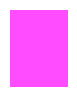

In [13]:
img = create_img(1., 0.3, 1.)

logger.step(
    img=img,
    score=0.983,
    step=1,
    params={'x': 31},
)

plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.axis('off');

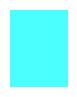

In [14]:
img = create_img(0.3, 1., 1.)

logger.step(
    img=img,
    score=0.999,
    step=2,
    params={'x': 100},
)

plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.axis('off');

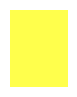

In [15]:
img = create_img(1., 1., 0.3)

logger.step(
    img=img,
    score=0.7,
    step=3,
    params={'x': 13},
)

plt.figure(figsize=(1, 1))
plt.imshow(img)
plt.axis('off');

In [16]:
logger.end({'x': 1.})

## Создание OptunaPipeline

In [26]:
from src import transforms

list_type_transforms = [
    transforms.PerspectiveTransform,
    transforms.GridDropoutTransform,
]

In [27]:
from src.base import BaseModel


class RandomModel(BaseModel):
    def __init__(self, model: Any):
        super().__init__(model=model)

    def predict(self, img: Any) -> float:
        return np.random.rand()


model = RandomModel(model=None)

In [28]:
from src.utils.dataset import AttackDataset

dataset = AttackDataset('notebooks/example_dataset')
type(dataset[0])

dict

In [29]:
from src.pipeline import PipelineAttackOptunaImg


direction = 'minimize'

logger = LoggerOptuna(
    direction=direction,
    description='model=RandomModel',
    experiment_name='test_optuna_attack_pipeline_with_logger',
)

optuna_attack_pipeline = PipelineAttackOptunaImg(
    model=model,
    list_type_transforms=list_type_transforms,
    logger=logger,
)

In [30]:
optuna_attack_pipeline.optimize(
    data=dataset[0]['img'],
    direction=direction,
    n_trials=30,
    timeout=None,
    show_progress=True,
)

Best trial: 1. Best value: 0.0137702: 100%|██████████| 30/30 [00:01<00:00, 29.90it/s]
